In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import os

In [2]:
# os.chdir(r"C:\Users\JxLee\Documents\GitHub\FYP2021")
os.path.exists(r"b03-025")

True

img.shape: (92, 281)


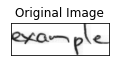

In [3]:
#INPUT IMAGE
img = cv.imread(r'b03-025\b03-025-01-09.png',0)
plt.subplot(2,3,1),plt.imshow(img,'gray',vmin=0,vmax=255)
plt.title("Original Image")
plt.xticks([]),plt.yticks([])
print('img.shape:',img.shape)
plt.show()

img.shape: (92, 281)


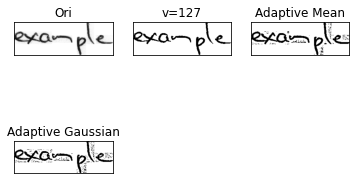

In [4]:
#binarization



ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
uth2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)bpl
 
 titles = ['Ori','v=127','Adaptive Mean','Adaptive Gaussian']
(images = [img,th1,th2,th3]2,
3for i in range(4):,1    ),plt.imshow(imgi+,th1ay',1min=0images[i]ax=255)ina    l Image")
titles[i]lt.    yticks([])
print('#mg.shape:',img.shatimg.lt12how#img.shapee

[]

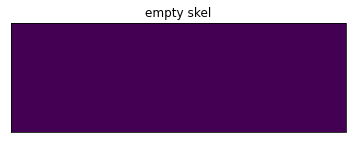

In [13]:
thImg = images[1]

#empty skenleton
size = np.size(thImg)
skel = np.zeros(thImg.shape, np.uint8)
skel[skel == 0] = 255

plt.imshow(skel,'white')
plt.title('empty skel')
plt.xticks([]),plt.yticks([])
plt.plot()g.shape



[]

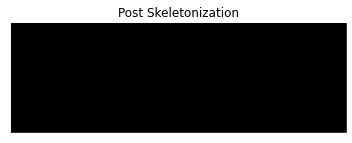

In [15]:
# cross shaped kernel
element = cv.getStructuringElement(cv.MORPH_CROSS, (3,3))
count=0
#Loop Steps for skeletonizations
while True:
    count+=1
    #Step 2: Open image
    o = cv.morphologyEx(thImg, cv.MORPH_OPEN, element)
    #Step 3: Substract open from original image
    temp = cv.subtract(thImg, o)
    #Step 4: Erode the original image and refine the skeleton
    eroded = cv.erode(thImg, element)
    skel = cv.bitwise_or(skel,temp)
    thImg = eroded.copy()

    # Step 5: If there are no white pixels left ie.. the image has been completely eroded, quit the loop
    if size - cv.countNonZero(thImg)==0 or count==100:
        break


plt.imshow(skel,'gray')
plt.title('Post Skeletonization')
plt.xticks([]),plt.yticks([])
plt.plot()